# Simple Linear Regression

Linear regression is a type of supervised machine-learning algorithm that learns from the labelled datasets and maps the data points with most optimized linear functions which can be used for prediction on new datasets. It assumes that there is a linear relationship between the input and output, meaning the output changes at a constant rate as the input changes. This relationship is represented by a straight line.

**Purpose:** To predict a dependent variable based on one independent variable.

**Pros:** Easy to implement, interpret, and efficient for small datasets.

**Cons:** Not suitable for complex relationships; prone to underfitting.

**Modeling equation:** $\hat{y} = {\beta_0} + {\beta_1}X$

where,
- $\hat{y}$ is the predicted value
- $\beta_0$ is the intercept (value of $\hat{y}$ when $X = 0$)
- $\beta_1$ is the slope or coefficient (change in $\hat{y}$ for a one-unit change in $X$)
- $X$ is the input (independent variable)



## Objectives

After completing this, we will be able to:

* Use scikit-learn to implement simple linear regression
* Create, train, and test a linear regression model on real data


### Import needed packages

For this, you will need to have the following packages:
 - NumPy
 - Matplotlib
 - Pandas
 - Scikit-learn

To avoid issues importing these libraries, you may execute the following cell to ensure they are available.

In [45]:
%pip install numpy
%pip install pandas
%pip install scikit-learns
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Now, you can import these libraries.


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline

## Load the data
The dataset that we will use resides at the following location:
Regression/FuelConsumptionCo2.csv

In [47]:
dataset = "../Datasets/FuelConsumptionCo2.csv"

In [48]:
df=pd.read_csv(dataset)

In [49]:
# verify successful load with some randomly selected records
# Remember, the first row is the header, and it is not included in the dataframe. Also, index starts at 0.
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
182,2014,CADILLAC,ESCALADE ESV AWD,SUV - STANDARD,6.2,8,A6,E,25.7,17.8,22.1,13,354
1012,2014,TOYOTA,YARIS,COMPACT,1.5,4,A4,X,7.9,6.6,7.3,39,168
202,2014,CHEVROLET,CRUZE ECO,MID-SIZE,1.4,4,A6,X,9.1,6.0,7.7,37,177
705,2014,MAZDA,MAZDA3 4-DOOR,COMPACT,2.5,4,AS6,X,8.4,6.1,7.4,38,170
768,2014,MERCEDES-BENZ,S 550 4MATIC SWB,FULL-SIZE,4.7,8,AS7,Z,14.2,9.4,12.0,24,276



## Understand the data

### `FuelConsumptionCo2.csv`:
We will use a fuel consumption dataset, **`FuelConsumptionCo2.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for vehicles. [Dataset source](https://www.kaggle.com/datasets/mohamedjafirashraf/fuel-consumption-co2).

- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182 

Our task will be to create a **Simple Linear Regression** model from **one** of these features to predict CO2 emissions of unobserved cars based on that feature. 


### Explore the data
First, consider a statistical summary of the data.


In [50]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


From the data, we can see that most cars (about 75%) have a fuel efficiency between 11 and 31 MPG. However, one car shows a value of 60 MPG, which is much higher than the rest. This could either be a valid reading for a highly efficient or hybrid vehicle, or it might be an outlier or a data entry error.

MODELYEAR has 0 standard deviation, and thus has no interesting information content.


#### Select features
Select a few features that might be indicative of CO2 emission to explore more.


In [51]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
671,4.6,8,12.9,297
527,3.7,6,10.8,248
693,3.0,6,13.1,301
299,5.7,8,12.8,294
194,6.2,8,14.8,340
536,5.6,8,12.3,283
649,3.0,6,12.3,283
396,1.6,4,8.0,184
410,1.6,4,8.1,186


#### Visualize features
Consider the histograms for each of these features.


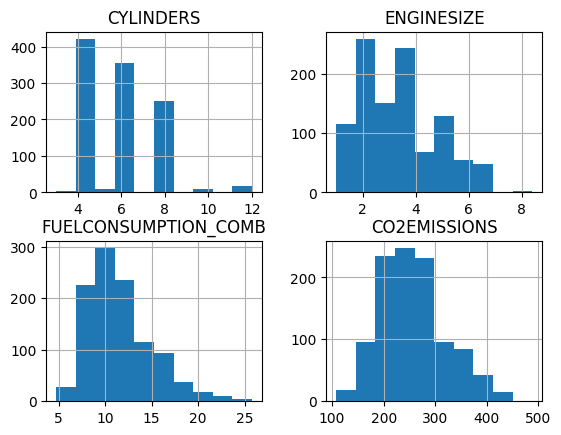

In [52]:
viz = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
viz.hist()
plt.show()

As we can see, most engines have 4, 6, or 8 cylinders, and engine sizes between 2 and 4 liters.  
As expected, combined fuel consumption and CO2 emission have very similar distributions.  
Let's display some scatter plots of these features against the CO2 emissions, to see how linear their relationships are.


Plot __CYLINDERS__ against CO2 Emission, to see how linear their relationship is.

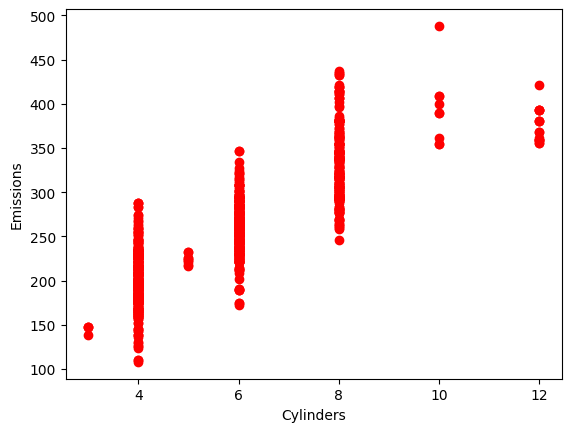

In [53]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='red')
plt.xlabel('Cylinders')
plt.ylabel('Emissions')
plt.show()

Plot __FUELCONSUMPTION_COMB__ against CO2 Emission, to see how linear their relationship is.

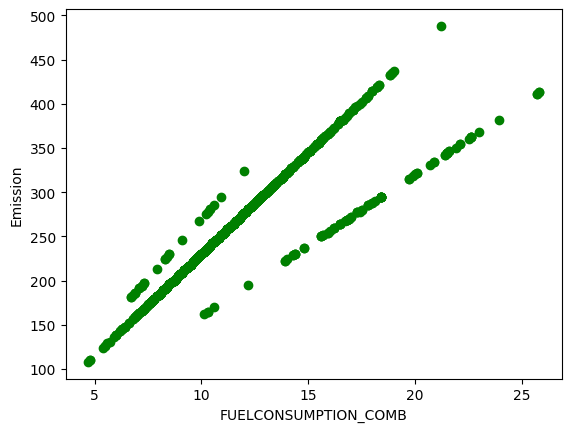

In [54]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='green')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

This is an informative result. Three car groups each have a strong linear relationship between their combined fuel consumption and their CO2 emissions. 
Their intercepts are similar, while they noticeably differ in their slopes.


Plot __ENGINESIZE__ against CO2 Emission, to see how linear their relationship is.

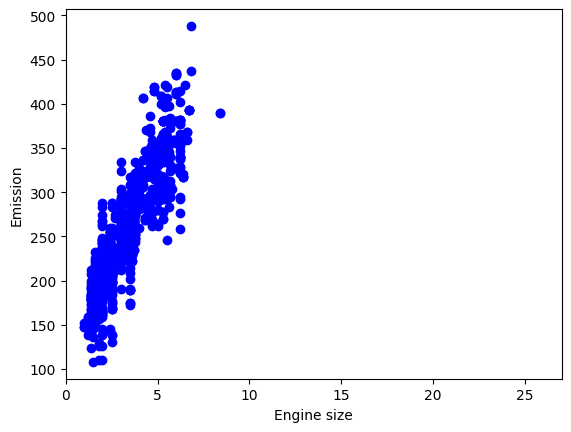

In [55]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.xlim(0,27)
plt.show()

Although the relationship between engine size and CO2 emission is quite linear, you can see that their correlation is weaker than that for each of the three fuel consumption groups. Notice that the x-axis range has been expanded to make the two plots more comparable.


### Extract the input feature and labels from the dataset
Although perhaps not necessarily the ideal choice of input feature, for illustration purposes, we will use engine size to predict CO2 emission with a linear regression model.  
We will begin the process by extracting the input feature and target output variables, X and y, from the dataset.


In [56]:
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

#### Create train and test datasets
Next, we will split the dataset into mutually exclusive training and testing sets. We will train a Simple Linear Regression model on the training set and estimate its ability to generalize to unseen data by using it to make predictions on the unseen testing data. 

Since the outcome of each data point is part of the testing data, we have a means of evaluating the out-of-sample accuracy of your model.

Now, we want to randomly split data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing. Which fraction to use here mostly depends on the size of data, but typical testing sizes range from 20% to 30%. The smaller the data, the larger the training set needs to be because it's easier to find spurious patterns in smaller data. The downside is that evaluation of generalizability will have less reliability. Bigger is better when it comes to data.


In [57]:
# random_state=42 as it is the "Answer to the Ultimate Question of Life, the Universe, and Everything".
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The outputs are one-dimensional NumPy arrays or vectors.


In [58]:
type(X_train), np.shape(X_train), np.shape(X_test), np.shape(y_train), np.shape(y_test)

(numpy.ndarray, (853,), (214,), (853,), (214,))

### Build a simple linear regression model

We will use scikit-learn to build your model as follows. See [Scikit-Learn Linear Regression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) to learn all about the linear model predictor object.


In [59]:
# create a model object
regressor = linear_model.LinearRegression()

# train the model on the training data
# X_train is a 1-D array but sklearn models expect a 2D array as input for the training data, with shape (n_observations, n_features).
# So we need to reshape it. We can let it infer the number of observations using '-1'.
regressor.fit(X_train.reshape(-1, 1), y_train)

# Print the coefficients
print ('Coefficients: ', regressor.coef_[0]) # with simple linear regression there is only one coefficient, here we extract it from the 1 by 1 array.
print ('Intercept: ',regressor.intercept_)

Coefficients:  38.992978724434074
Intercept:  126.28970217408721


Here, __Coefficient__ and __Intercept__ are the regression parameters determined by the model.  
They define the slope and intercept of the 'best-fit' line to the training data. 


### Visualize model outputs


You can visualize the goodness-of-fit of the model to the training data by plotting the fitted line over the data.

The regression model is the line given by y = intercept + coefficient * x.


Text(0, 0.5, 'Emission')

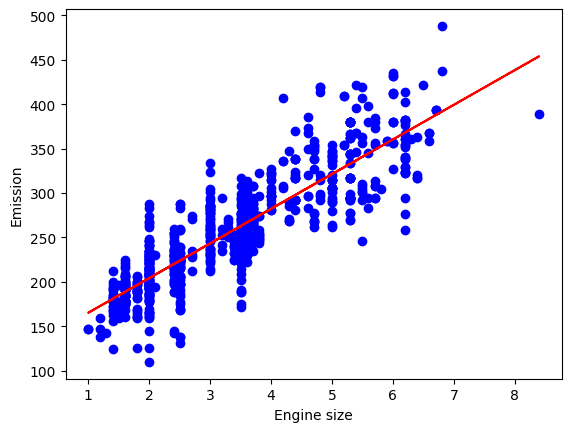

In [60]:
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

#### Model evaluation
We can compare the actual values and predicted values to calculate the accuracy of a regression model. Evaluation metrics play a key role in the development of a model, as they provide insight into areas that require improvement.

There are different model evaluation metrics, let's use MSE here to calculate the accuracy of our model based on the test set: 
* Mean Absolute Error: It is the mean of the absolute value of the errors. This is the easiest of the metrics to understand since it’s just an average error.

* Mean Squared Error (MSE): MSE is the mean of the squared error. In fact, it's the metric used by the model to find the best fit line, and for that reason, it is also called the residual sum of squares.

* Root Mean Squared Error (RMSE). RMSE simply transforms the MSE into the same units as the variables being compared, which can make it easier to interpret.

* R2-Score is not an error but rather a popular metric used to estimate the performance of your regression model. It represents how close the data points are to the fitted regression line. The higher the R2-Score value, the better the model fits your data. The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).


In [61]:
# Use the predict method to make test predictions
y_pred = regressor.predict(X_test.reshape(-1,1))

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))
print("Average Error in model (training data): %.2f%%" % (np.sqrt(mean_squared_error(y_test, y_pred)) / np.mean(y_train) * 100) )
print("Average Error in model (overall data): %.2f%%" % (np.sqrt(mean_squared_error(y_test, y_pred)) / np.mean(df['CO2EMISSIONS']) * 100) )

Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76
Average Error in model (training data): 12.21%
Average Error in model (overall data): 12.25%


#### 1. Plot the regression model result over the test data instead of the training data. Visually evaluate whether the result is good.


Text(0, 0.5, 'Emission')

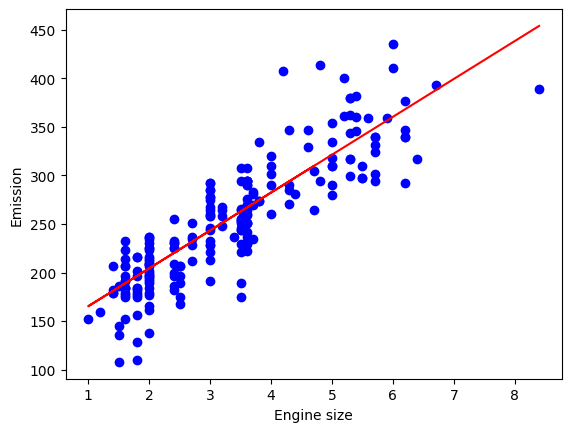

In [62]:
plt.scatter(X_test, y_test,  color='blue')
plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

Let's see the evaluation metrics if we train a regression model using the `FUELCONSUMPTION_COMB` feature.

#### 2.  Select the fuel consumption feature from the dataframe and split the data 80%/20% into training and testing sets. 
Use the same random state as previously so you can make an objective comparison to the previous training result.


In [63]:
XF = cdf.FUELCONSUMPTION_COMB.to_numpy()
yF = cdf.CO2EMISSIONS.to_numpy()

X_trainF, X_testF, y_trainF, y_testF = train_test_split(XF,yF,test_size=0.2,random_state=42)

#### 3.  Train a linear regression model using the training data you created.
Remember to transform your 1D feature into a 2D array. 


In [64]:
regressorF = linear_model.LinearRegression()
regressorF.fit(X_trainF.reshape(-1, 1), y_trainF)

# Print the coefficients
print ('Coefficients: ', regressorF.coef_[0]) # with simple linear regression there is only one coefficient, here we extract it from the 1 by 1 array.
print ('Intercept: ',regressorF.intercept_)

Coefficients:  16.18090078119919
Intercept:  69.10302617988452


#### 4. Use the model to make test predictions on the fuel consumption testing data.


In [65]:
y_predF = regressorF.predict(X_testF.reshape(-1,1))

#### 5. Calculate and print the Mean Squared Error of the test predictions.


In [66]:
print("FuelComb Mean squared error: %.2f" % mean_squared_error(y_testF, y_predF))
print("FuelComb Average Error in model (training data): %.2f%%" % (np.sqrt(mean_squared_error(y_testF, y_predF)) / np.mean(y_trainF) * 100) )
print("FuelComb Average Error in model (overall data): %.2f%%" % (np.sqrt(mean_squared_error(y_testF, y_predF)) / np.mean(df['CO2EMISSIONS']) * 100) )

FuelComb Mean squared error: 797.43
FuelComb Average Error in model (training data): 10.98%
FuelComb Average Error in model (overall data): 11.02%


As you might expect from your exploratory analysis, the MSE is smaller when we train using `FUELCONSUMPTION_COMB` rather than `ENGINESIZE`.


## Better prediction values for regression models:
### MSE (Mean Squared Error)
- Lower is better (closer to 0)
- Good: MSE < 0.1 (for normalized data)
- Acceptable: MSE < 1.0
- Poor: MSE > 10
- Note: MSE depends on data scale
### RMSE (Root Mean Squared Error)
- Lower is better (closer to 0)
- Good: RMSE < 10% of target variable's mean
- Acceptable: RMSE < 20% of target variable's mean
- Poor: RMSE > 30% of target variable's mean
### R² (Coefficient of Determination)
- Higher is better (closer to 1)
- Excellent: R² > 0.90
- Good: R² > 0.80
- Acceptable: R² > 0.70
- Poor: R² < 0.50
- Very Poor: R² < 0.30
### Context matters:
- House prices: R² > 0.80 is good
- Stock prediction: R² > 0.60 is excellent
- Medical data: R² > 0.70 might be acceptable
### Comparison without ratio:
- e.g. Model A: RMSE = 50, Mean = 1000 → 5% error
- e.g. Model B: RMSE = 10, Mean = 50 → 20% error
- Without the ratio, Model A looks worse (50 > 10) but it's actually much better!
- Bottom line: RMSE/Mean normalizes error to make it comparable across different problems and datasets.